# Aditya Rana
# I059
# B'Tech AI B2 Batch

### **Improved Techniques for Training GANs: Key Concepts**

#### **1. Feature Matching**
Feature matching is a technique used to address the instability of GAN training by providing a new objective for the generator.
*  **The Method:** Instead of directly maximizing the output of the discriminator, the generator is trained to match the expected value of features at an intermediate layer of the discriminator.
*  **Why it works:** By matching these statistics, the generator produces data that aligns with the features the discriminator currently finds most important for identifying real data.
*  **Performance:** It is particularly effective for semi-supervised learning and situations where regular GAN training becomes unstable.

#### **2. Mode Collapse**
 Mode collapse occurs when the generator finds a specific parameter setting where it always emits the same output.
*  **The Mechanism:** Because the discriminator processes each example independently, there is no coordination between its gradients to tell the generator's outputs to become more dissimilar.
*  **The Failure:** All generator outputs race toward a single point that the discriminator believes is highly realistic.  After collapse, the discriminator eventually learns to reject that point, but the generator simply pushes that single point around the space forever.

#### **3. Minibatch Discrimination**
 Minibatch discrimination is a strategy to avoid mode collapse by allowing the discriminator to look at multiple data examples in combination.
*  **How it works:** The discriminator computes the closeness between samples in a minibatch by calculating the $L_1$ distance between features transformed by a tensor T.
*  **The Output:** These distance-based features are concatenated with the original intermediate features and fed into the next layer of the discriminator.
*  **Impact:** The discriminator can now penalize the generator if its samples are too similar to each other, which helps maintain diversity in the generated distribution.



#### **4. Stabilization Terms**
* **a.  Historical Averaging:** A penalty term added to each player's cost: $||\theta - \frac{1}{t}\sum_{i=1}^t \theta[i]||^2$, where $\theta[i]$ represents past parameters.  It helps the model find equilibria in non-convex games where standard gradient descent might enter stable orbits instead of converging.
* **b.  One-sided Label Smoothing:** This technique replaces positive target labels (1) with a smoothed value like 0.9 while leaving negative targets at 0.  This prevents the discriminator from becoming too confident and creating areas where the model has no incentive to move closer to the real data.
* **c.  Virtual Batch Normalization (VBN):** Regular batch normalization causes an input x to depend on other inputs in the same minibatch.  VBN normalizes each example based on statistics from a fixed reference batch and the example itself to avoid this dependency.

#### **5. Summary of Suggestions to Stabilize Training**
1.  **Feature Matching:** Prevents overtraining on the current discriminator.
2.  **Minibatch Discrimination:** Encourages sample diversity to prevent mode collapse.
3.  **Historical Averaging:** Helps find equilibria in competitive games.
4.  **One-sided Label Smoothing:** Reduces vulnerability to adversarial confidence.
5.  **Virtual Batch Normalization:** Reduces inter-sample dependency during normalization.

#### **6. JS Divergence vs. KL Divergence**
*  **Definition:** In the original GAN framework, the minimax game minimizes the Jensen-Shannon (JS) Divergence between the data distribution and the model distribution when the discriminator is optimal.
*  **JS Divergence:** It is symmetric and always provides a finite, bounded value between 0 and $\log(2)$.
* **Comparison to KL:** KL Divergence (often used in VAEs) is asymmetric and can become infinite if the distributions do not overlap. JS divergence is generally preferred for GANs because it provides a smoother gradient for training even when distributions have different supports.

#### **7. Wasserstein Distance (WGAN)**
* **Definition:** Also known as the Earth Mover's distance, it measures the minimum "cost" to transform one distribution into another.
* **Why it is better:** Unlike JS or KL divergence, Wasserstein distance is continuous and provides useful gradients even when the two distributions have non-overlapping supports.
* **Example:** If you have two parallel lines in 2D space, the JS divergence is constant regardless of how far apart they are (providing no gradient), while the Wasserstein distance is proportional to the actual distance between the lines.



#### **8. Lipschitz Continuity**
* **Definition:** A function f is K-Lipschitz continuous if the difference in its output is bounded by a constant K times the difference in its input: $|f(x_1) - f(x_2)| \leq K |x_1 - x_2|$.
* **In GANs:** This property ensures that the gradients of the discriminator (or critic) do not explode, which is a mathematical requirement for the stability of the Wasserstein GAN objective.

#### **9. Original GAN vs. WGAN Changes**
To implement a Wasserstein GAN (WGAN) instead of an original GAN, the following changes are typically made:
1. **No Sigmoid:** Remove the sigmoid activation from the last layer of the discriminator (now called a "critic").
2. **No Logarithm:** Use the Earth Mover loss instead of the log-likelihood loss.
3. **Weight Clipping:** Clip the weights of the critic to a small fixed range (e.g., $[-0.01, 0.01]$) to enforce the Lipschitz constraint.
4. **Optimizer:** Use RMSProp or SGD instead of Adam to avoid momentum-based instability.

## Task 2: WGAN Implementation on CIFAR-10

In [3]:
%pip install matplotlib -q

Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### Load and Preprocess CIFAR-10

c:\Users\Aditya Rana\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Dataset size: 50000, Batches: 781


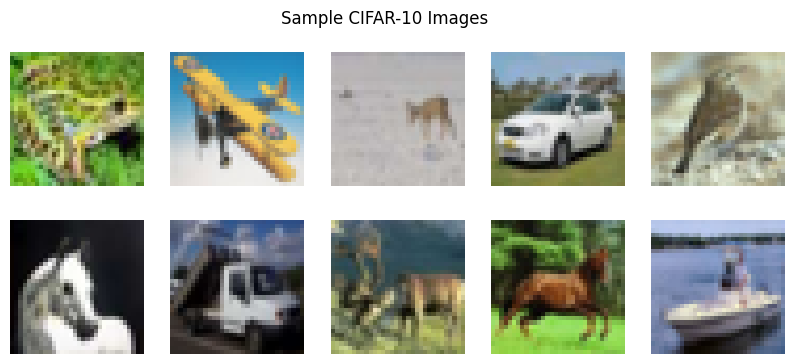

In [5]:
BATCH_SIZE = 64
NOISE_DIM = 128
CLIP_VALUE = 0.01
N_CRITIC = 5

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),  # normalize to [-1, 1]
])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Dataset size: {len(trainset)}, Batches: {len(dataloader)}")

# Plot some samples
imgs, _ = next(iter(dataloader))
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    img = imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    ax.imshow(img)
    ax.axis("off")
plt.suptitle("Sample CIFAR-10 Images")
plt.show()

In [6]:
# Hyperparameters already defined above:
# BATCH_SIZE=64, NOISE_DIM=128, CLIP_VALUE=0.01, N_CRITIC=5

### Build the Critic (Discriminator) — No Sigmoid, Linear Output

In [7]:
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1),  # NO sigmoid — this is a critic
        )

    def forward(self, x):
        return self.model(x)

critic = Critic().to(device)
print(critic)

Critic(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=8192, out_features=128, bias=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Linear(in_features=128, out_features=1, bias=True)
  )
)


### Build the Generator

In [8]:
class Generator(nn.Module):
    def __init__(self, noise_dim=NOISE_DIM):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256 * 8 * 8),
            nn.Unflatten(1, (256, 8, 8)),
            nn.BatchNorm2d(256, momentum=0.8),

            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128, momentum=0.8),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64, momentum=0.8),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 3, 3, padding=1),
            nn.Tanh(),  # output range [-1, 1]
        )

    def forward(self, z):
        return self.model(z)

generator = Generator().to(device)
print(generator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=128, out_features=16384, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(256, 8, 8))
    (2): BatchNorm2d(256, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.8, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): Tanh()
  )
)


### Wasserstein Loss and Optimizers (RMSProp as per WGAN paper)

In [9]:
# RMSProp optimizer as per the WGAN paper
critic_optimizer = optim.RMSprop(critic.parameters(), lr=5e-5)
generator_optimizer = optim.RMSprop(generator.parameters(), lr=5e-5)

### Plot Generated Images

In [10]:
def plot_generated(generator, n=10):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(n, NOISE_DIM, device=device)
        imgs = generator(noise).cpu().numpy()
    generator.train()

    imgs = imgs * 0.5 + 0.5  # rescale to [0, 1]
    imgs = np.clip(imgs, 0, 1)

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.5))
    for i, ax in enumerate(axes):
        ax.imshow(np.transpose(imgs[i], (1, 2, 0)))  # CHW -> HWC
        ax.axis("off")
    plt.tight_layout()
    plt.show()

### Train the WGAN

Epoch 1/10 | Critic loss: -0.0745 | Generator loss: 0.2886


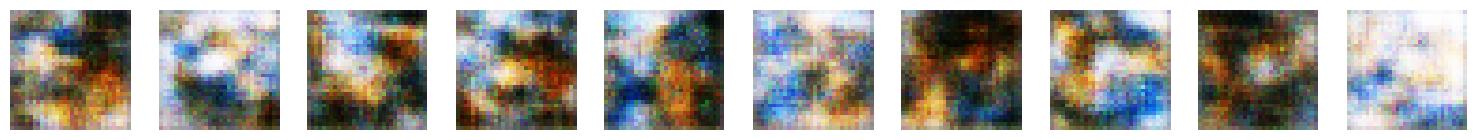

Epoch 2/10 | Critic loss: -0.0894 | Generator loss: 0.1388


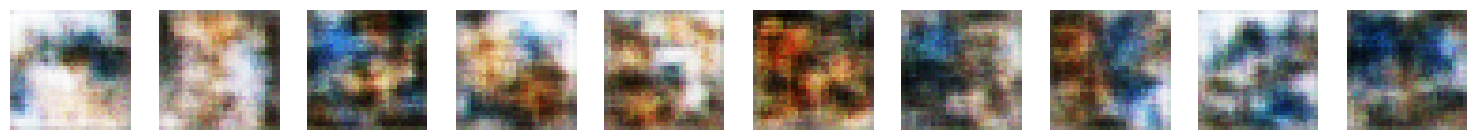

Epoch 3/10 | Critic loss: -0.0730 | Generator loss: 0.1085


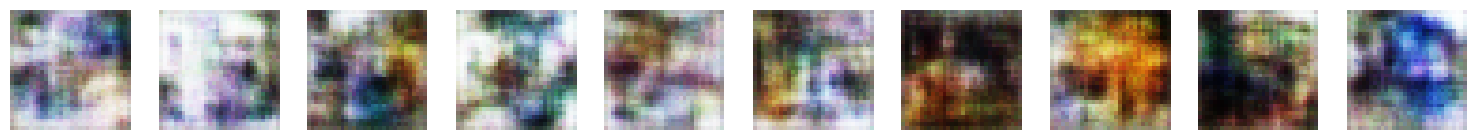

Epoch 4/10 | Critic loss: -0.0615 | Generator loss: 0.0871


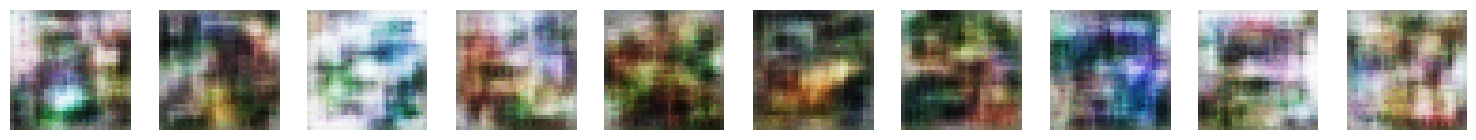

Epoch 5/10 | Critic loss: -0.0591 | Generator loss: 0.0747


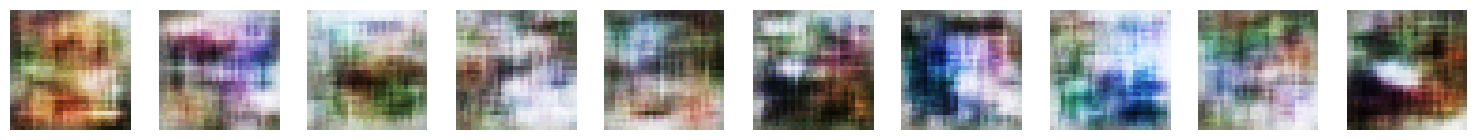

Epoch 6/10 | Critic loss: -0.0591 | Generator loss: 0.0767


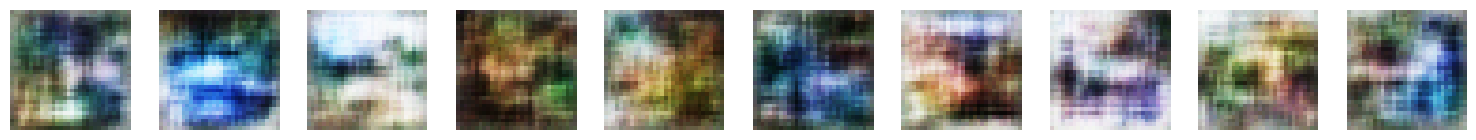

Epoch 7/10 | Critic loss: -0.0578 | Generator loss: 0.0932


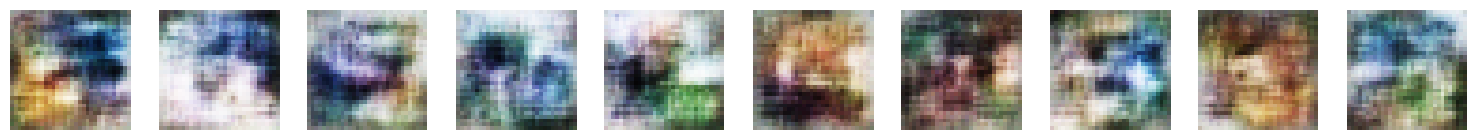

Epoch 8/10 | Critic loss: -0.0595 | Generator loss: 0.0933


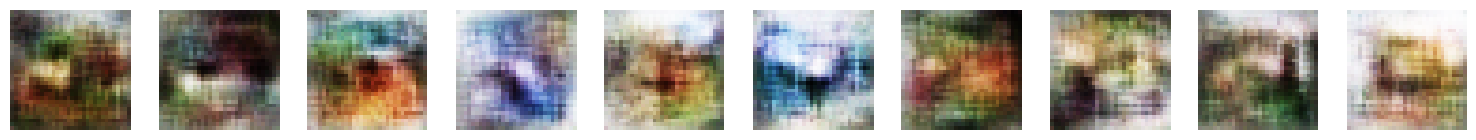

Epoch 9/10 | Critic loss: -0.0617 | Generator loss: 0.0954


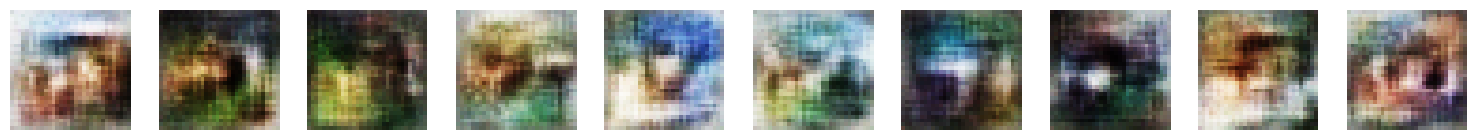

Epoch 10/10 | Critic loss: -0.0613 | Generator loss: 0.0955


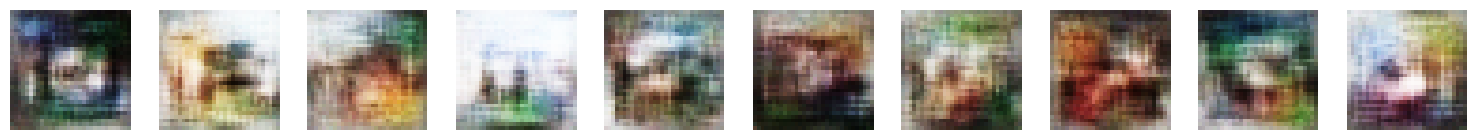

In [11]:
EPOCHS = 10
c_losses = []
g_losses = []

for epoch in range(1, EPOCHS + 1):
    epoch_c, epoch_g = [], []

    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)

        # ---- Train Critic ----
        critic_optimizer.zero_grad()
        noise = torch.randn(BATCH_SIZE, NOISE_DIM, device=device)
        fake_imgs = generator(noise).detach()

        c_loss = critic(fake_imgs).mean() - critic(real_imgs).mean()  # Wasserstein loss
        c_loss.backward()
        critic_optimizer.step()

        # Weight clipping to enforce Lipschitz constraint
        for p in critic.parameters():
            p.data.clamp_(-CLIP_VALUE, CLIP_VALUE)

        epoch_c.append(c_loss.item())

        # ---- Train Generator every N_CRITIC steps ----
        if i % N_CRITIC == 0:
            generator_optimizer.zero_grad()
            noise = torch.randn(BATCH_SIZE, NOISE_DIM, device=device)
            fake_imgs = generator(noise)
            g_loss = -critic(fake_imgs).mean()  # generator wants critic to score fakes high
            g_loss.backward()
            generator_optimizer.step()
            epoch_g.append(g_loss.item())

    avg_c = np.mean(epoch_c)
    avg_g = np.mean(epoch_g)
    c_losses.append(avg_c)
    g_losses.append(avg_g)
    print(f"Epoch {epoch}/{EPOCHS} | Critic loss: {avg_c:.4f} | Generator loss: {avg_g:.4f}")
    plot_generated(generator)

### Training Loss Plot

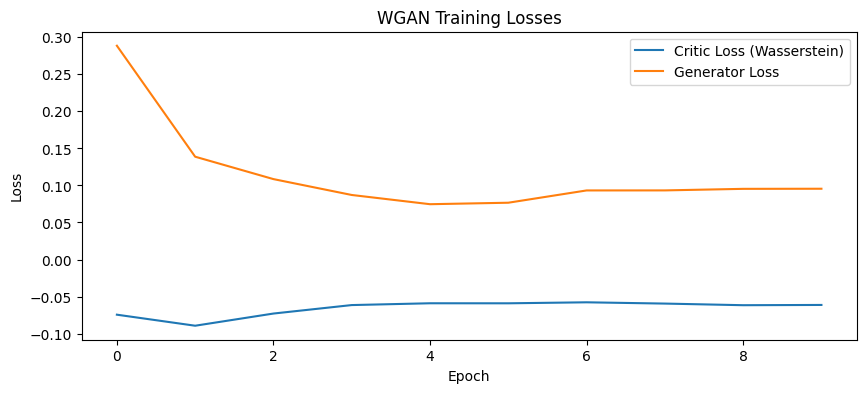

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(c_losses, label="Critic Loss (Wasserstein)")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("WGAN Training Losses")
plt.show()

### Final Generated Images

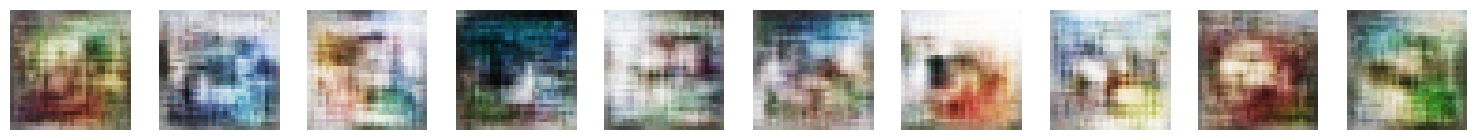

In [13]:
plot_generated(generator, n=10)

### Conclusion

- Implemented a **Wasserstein GAN (WGAN)** on the CIFAR-10 dataset using TensorFlow/Keras.
- Key WGAN changes vs original GAN:
  - **No sigmoid** on the critic's output (linear activation).
  - **Wasserstein loss** (Earth Mover distance) instead of binary cross-entropy.
  - **Weight clipping** on the critic to enforce the Lipschitz constraint.
  - **RMSProp** optimizer instead of Adam for stable training.
  - Critic is trained **5 times** for every generator update.
- The Wasserstein loss provides a meaningful training signal even when distributions don't overlap, making training more stable than the original GAN.